# August 2026 mobile — round-1 sensitivity gradient

Central-difference first and second derivatives of the **Dec-15 2026 28d-MA, post-headwind**
with respect to each numeric non-holiday knob, run twice: once at the shipped
`seasonality_regime='auto'` center and once with the regime forced to `multiplicative`.

**Target 17,923,869 ± 50,000** (July delivered). The shipped build reads 17,601,155 →
gap **+322,714**.

The gap is a calibration artifact of the 2026-07-31 `m` → `p` methodology swap, not a data
change. Closing it raises the fitted trend: in calendar-aligned terms the search must move
Dec-15 year-over-year growth from **12.35% → 14.41%** against a measured organic rate of
**11.60%**. `yoy_dec15_pct` is reported on every probe so that cost stays visible.

Scored on Dec-15 only. Seam handoff is **reported, never trained on**.

Context and scope decisions: `_index.md` in this directory.

In [1]:
# [setup]
import importlib.util
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np
import pandas as pd

REPO = Path.cwd()
while not (REPO / "src" / "mozaic_daily").exists() and REPO != REPO.parent:
    REPO = REPO.parent
sys.path.insert(0, str(REPO / "src"))

HERE = REPO / "research/param-scans/mobile-aug"
PLOTS = HERE / "plots"
PLOTS.mkdir(exist_ok=True)

_spec = importlib.util.spec_from_file_location(
    "mobile_scoring", REPO / "scripts" / "mobile_scoring.py")
mobile_scoring = importlib.util.module_from_spec(_spec)
_spec.loader.exec_module(mobile_scoring)

from mozaic_daily.adjustments import load_forecast
from mozaic_daily.seam_ma import display_ma

FORECAST_START = pd.Timestamp(mobile_scoring.FORECAST_START)
DEC15 = pd.Timestamp(mobile_scoring.DEC15)
TARGET = mobile_scoring.TARGET_DEC15
TOLERANCE = mobile_scoring.TOLERANCE
HEADWIND = mobile_scoring.load_headwind(mobile_scoring.DEFAULT_HEADWIND)

# The three runs. 'auto' is the shipped regime; the other two re-ran the same 11 probes
# with the regime forced. See [reconciliation] for why 'additive' moves nothing at the total.
REGIMES = {"auto": "round1", "multiplicative": "round1_mult", "additive": "round1_addi"}

# Display window: actuals from Jan 1 through the end of the forecast, per the canonical
# plot format used across this repo's parameter sweeps.
DISPLAY_START = pd.Timestamp("2026-01-01")
DISPLAY_END = pd.Timestamp("2026-12-31")

print(f"repo   {REPO}")
print(f"seam   {FORECAST_START.date()}   target {TARGET:,} +-{TOLERANCE:,}")
print(f"headwind at Dec-15: {mobile_scoring.headwind_ramp(DEC15, HEADWIND):+,.0f}")

/Users/brendanwells/work/mozaic-daily/.venv/lib/python3.10/site-packages/google/api_core/_python_version_support.py:266: FutureWarning: You are using a Python version (3.10.19) which Google will stop supporting in new releases of google.api_core once it reaches its end of life (2026-10-04). Please upgrade to the latest Python version, or at least Python 3.11, to continue receiving updates for google.api_core past that date.
  warnings.warn(message, FutureWarning)
/Users/brendanwells/work/mozaic-daily/.venv/lib/python3.10/site-packages/google/api_core/_python_version_support.py:266: FutureWarning: You are using a Python version (3.10.19) which Google will stop supporting in new releases of google.cloud.bigquery_storage_v1 once it reaches its end of life (2026-10-04). Please upgrade to the latest Python version, or at least Python 3.11, to continue receiving updates for google.cloud.bigquery_storage_v1 past that date.
  warnings.warn(message, FutureWarning)


repo   /Users/brendanwells/work/mozaic-daily
seam   2026-07-28   target 17,923,869 +-50,000
headwind at Dec-15: -27,162


/Users/brendanwells/work/mozaic-daily/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# [load-scores]
scores, deriv, centers = {}, {}, {}
for regime, tag in REGIMES.items():
    s = pd.read_csv(HERE / f"{tag}_scores.csv")
    d = pd.read_csv(HERE / f"{tag}_derivatives.csv")
    # Curvature over the same +-10% span the effect column uses: 0.5 * d2 * (0.1*center)^2.
    # When this is a large fraction of the linear term, the extrapolation is untrustworthy
    # even for a single knob in isolation.
    d["curvature_over_span"] = 0.5 * d["d2"] * (0.10 * d["center"]) ** 2
    d["nonlinearity"] = (d["curvature_over_span"].abs()
                         / d["effect_per_10pct"].abs().replace(0, np.nan))
    scores[regime], deriv[regime] = s, d
    centers[regime] = s.loc[s["axis"] == "(center)"].iloc[0]

F0 = float(centers["auto"]["dec15_post"])          # the shipped build
GAP = TARGET - F0
PRIOR_MA = float(centers["auto"]["prior_dec15_ma"])
YOY_NEEDED = ((TARGET - mobile_scoring.headwind_ramp(DEC15, HEADWIND)) / PRIOR_MA - 1) * 100

print(f"Shipped center (auto)      : {F0:,.0f}")
print(f"Target                     : {TARGET:,.0f} +-{TOLERANCE:,}")
print(f"Gap to close               : {GAP:+,.0f}")
print(f"Center YoY at Dec-15       : {centers['auto']['yoy_dec15_pct']:.2f}%")
print(f"YoY required to hit target : {YOY_NEEDED:.2f}%")
print(f"Measured organic growth    : 11.60%")

Shipped center (auto)      : 17,601,155
Target                     : 17,923,869 +-50,000
Gap to close               : +322,714
Center YoY at Dec-15       : 12.35%
YoY required to hit target : 14.41%
Measured organic growth    : 11.60%


In [3]:
# [regime-comparison]
# The regime's OWN effect: center vs center, everything else identical. On mobile the regime
# sets seasonality_mode only -- growth stays volume-driven, unlike desktop, where forcing
# multiplicative was the largest single lever in the summer-trough search.
auto_c = centers["auto"]
regime_effect = {r: float(centers[r]["dec15_post"]) - float(auto_c["dec15_post"])
                for r in REGIMES}

rows = pd.DataFrame([
    {"regime": r, "dec15_post": float(centers[r]["dec15_post"]),
     "gap_to_target": float(centers[r]["gap_to_target"]),
     "yoy_dec15_pct": float(centers[r]["yoy_dec15_pct"]),
     "seam_step": float(centers[r]["seam_step"]),
     "seam_slope_kink": float(centers[r]["seam_slope_kink"])}
    for r in REGIMES])
display(rows.style.format({"dec15_post": "{:,.0f}", "gap_to_target": "{:+,.0f}",
                           "yoy_dec15_pct": "{:.2f}", "seam_step": "{:+,.0f}",
                           "seam_slope_kink": "{:+,.0f}"}))

for r, v in regime_effect.items():
    if r == "auto":
        continue
    print(f"Regime effect ({r} - auto): {v:+,.0f} DAU at Dec-15  "
          f"= {v / GAP * 100:.1f}% of the {GAP:+,.0f} gap")
print("\n`additive` lands within a couple of DAU of `auto`. That is NOT a failed override --")
print("the config reaches the model and 63 of 64 leaf tiles move. See [reconciliation].")

,regime,dec15_post,gap_to_target,yoy_dec15_pct,seam_step,seam_slope_kink
0,auto,"17,601,155","-322,714",12.35,"-9,989","-2,954"
1,multiplicative,"17,618,697","-305,172",12.46,"-10,719","-3,956"
2,additive,"17,601,155","-322,714",12.35,"-9,992","-2,964"


Regime effect (multiplicative - auto): +17,542 DAU at Dec-15  = 5.4% of the +322,714 gap
Regime effect (additive - auto): -0 DAU at Dec-15  = -0.0% of the +322,714 gap

`additive` lands within a couple of DAU of `auto`. That is NOT a failed override --
the config reaches the model and 63 of 64 leaf tiles move. See [reconciliation].


In [4]:
# [derivative-table]
# d1 = (f(+h) - f(-h)) / 2h            first derivative of Dec-15 wrt the knob
# d2 = (f(+h) - 2f(0) + f(-h)) / h^2   curvature -- how fast the linear estimate degrades
#
# Rank by `effect_per_10pct`, NOT d1: the knobs' units differ by three orders of magnitude
# (cps ~0.035 vs n_changepoints ~25), so raw slopes are not comparable across rows.
for regime in REGIMES:
    d = deriv[regime]
    ranked = d.reindex(d["effect_per_10pct"].abs().sort_values(ascending=False).index)
    print(f"\n=== regime={regime}  (center {centers[regime]['dec15_post']:,.0f}) ===")
    display(ranked[["axis", "center", "delta", "f_minus", "f_center", "f_plus",
                    "d1", "d2", "effect_per_10pct", "curvature_over_span", "nonlinearity"]]
            .style.format({"f_minus": "{:,.0f}", "f_center": "{:,.0f}", "f_plus": "{:,.0f}",
                           "d1": "{:,.0f}", "d2": "{:,.3g}",
                           "effect_per_10pct": "{:+,.0f}",
                           "curvature_over_span": "{:+,.0f}", "nonlinearity": "{:.1%}"}))
    print(f"sum of all five 10% effects: {d['effect_per_10pct'].sum():+,.0f}  "
          f"(vs gap {GAP:+,.0f})")
    print(f"all-favourable 10% budget:   {d['effect_per_10pct'].abs().sum():+,.0f}  "
          f"= {d['effect_per_10pct'].abs().sum() / GAP * 100:.0f}% of the gap")


=== regime=auto  (center 17,601,155) ===


,axis,center,delta,f_minus,f_center,f_plus,d1,d2,effect_per_10pct,curvature_over_span,nonlinearity
1,changepoint-range,0.750000,0.025000,"17,625,062","17,601,155","17,584,021","-820,815",1.08e+07,"-61,561","+30,478",49.5%
0,changepoint-prior-scale,0.035000,0.003500,"17,607,503","17,601,155","17,597,095","-1,486,806",1.87e+08,"-5,204","+1,144",22.0%
2,n-changepoints,25.000000,3.000000,"17,595,952","17,601,155","17,602,126","1,029",-470,"+2,572","-1,469",57.1%
4,seasonality-prior-scale,0.100000,0.010000,"17,600,096","17,601,155","17,603,793","184,842",1.58e+07,"+1,848",+790,42.7%
3,recent-weeks,13.000000,2.000000,"17,602,898","17,601,155","17,604,491",398,1.27e+03,+518,"+1,073",207.2%


sum of all five 10% effects: -61,826  (vs gap +322,714)
all-favourable 10% budget:   +71,704  = 22% of the gap

=== regime=multiplicative  (center 17,618,697) ===


,axis,center,delta,f_minus,f_center,f_plus,d1,d2,effect_per_10pct,curvature_over_span,nonlinearity
1,changepoint-range,0.750000,0.025000,"17,647,560","17,618,697","17,605,443","-842,350",2.5e+07,"-63,176","+70,244",111.2%
0,changepoint-prior-scale,0.035000,0.003500,"17,624,822","17,618,697","17,613,820","-1,571,829",1.02e+08,"-5,501",+624,11.3%
2,n-changepoints,25.000000,3.000000,"17,606,819","17,618,697","17,616,359","1,590",-1.58e+03,"+3,975","-4,936",124.2%
4,seasonality-prior-scale,0.100000,0.010000,"17,618,460","17,618,697","17,624,277","290,817",5.34e+07,"+2,908","+2,672",91.9%
3,recent-weeks,13.000000,2.000000,"17,619,750","17,618,697","17,618,728",-256,271,-332,+229,69.0%


sum of all five 10% effects: -62,126  (vs gap +322,714)
all-favourable 10% budget:   +75,893  = 24% of the gap

=== regime=additive  (center 17,601,155) ===


,axis,center,delta,f_minus,f_center,f_plus,d1,d2,effect_per_10pct,curvature_over_span,nonlinearity
1,changepoint-range,0.750000,0.025000,"17,625,062","17,601,155","17,584,022","-820,801",1.08e+07,"-61,560","+30,483",49.5%
0,changepoint-prior-scale,0.035000,0.003500,"17,607,503","17,601,155","17,597,095","-1,486,939",1.87e+08,"-5,204","+1,144",22.0%
2,n-changepoints,25.000000,3.000000,"17,595,953","17,601,155","17,602,126","1,029",-470,"+2,572","-1,469",57.1%
4,seasonality-prior-scale,0.100000,0.010000,"17,600,097","17,601,155","17,603,795","184,870",1.58e+07,"+1,849",+791,42.8%
3,recent-weeks,13.000000,2.000000,"17,602,899","17,601,155","17,604,492",398,1.27e+03,+518,"+1,073",207.3%


sum of all five 10% effects: -61,826  (vs gap +322,714)
all-favourable 10% budget:   +71,703  = 22% of the gap


In [5]:
# [load-curves]
# Rebuild each probe's post-headwind display 28d-MA so the gradient can be read as curves,
# not just endpoint numbers. Actuals come from a probe's training rows (identical across all
# probes -- one shared raw pull), which under `p` equal raw actuals exactly.
def probe_curve(slug):
    path = (HERE / "results" / slug
            / f"mozaic_daily_forecast.{FORECAST_START.date()}.gm-D.adj-p.parquet")
    df, _ = load_forecast(str(path), require_state=["p"])
    daily = mobile_scoring.mobile_daily_series(df)
    ma = display_ma(daily["target_date"], daily["dau"], FORECAST_START)
    ramp = pd.Series([mobile_scoring.headwind_ramp(d, HEADWIND) for d in ma.index],
                     index=ma.index)
    ramp[ma.index < FORECAST_START] = 0.0
    return ma + ramp, daily

curves, actuals_daily = {}, None
for regime in REGIMES:
    for _, row in scores[regime].iterrows():
        curves[(regime, row["label"])], daily = probe_curve(row["slug"])
        if actuals_daily is None:
            actuals_daily = daily

actual = actuals_daily[actuals_daily["data_type"] == "training"].set_index("target_date")["dau"]
actual_ma = actual.rolling(28).mean()

print(f"loaded {len(curves)} probe curves across {len(REGIMES)} regimes; "
      f"actuals through {actual.index.max().date()}")

loaded 33 probe curves across 3 regimes; actuals through 2026-07-27


In [6]:
# [plot-helpers]
def millions(x, _pos):
    # Two decimals: the probes sit within ~0.3M of each other, so whole-million labels would
    # render several adjacent ticks identically.
    return f"{x / 1e6:.2f}M"

def base_axes(title):
    fig, ax = plt.subplots(figsize=(13, 6))
    ax.axhspan(TARGET - TOLERANCE, TARGET + TOLERANCE, color="tab:green", alpha=0.12,
               zorder=0, label=f"target band {TARGET:,.0f} +-{TOLERANCE:,}")
    ax.axhline(TARGET, color="tab:green", lw=1.2, ls="--", zorder=1)
    a = actual_ma[(actual_ma.index >= DISPLAY_START) & (actual_ma.index <= DISPLAY_END)].dropna()
    ax.plot(a.index, a.values, color="black", lw=2.0, label="actuals (28d-MA)", zorder=5)
    ax.axvline(FORECAST_START, color="grey", lw=1.0, ls=":", zorder=2)
    ax.set_title(title, fontsize=12)
    ax.set_ylabel("DAU (28-day MA)")
    ax.yaxis.set_major_formatter(plt.FuncFormatter(millions))
    ax.xaxis.set_major_locator(mdates.MonthLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))
    plt.setp(ax.get_xticklabels(), rotation=45, ha="right")
    ax.grid(alpha=0.25)
    return fig, ax

def draw(ax, regime, label, color, ls, text):
    curve = curves[(regime, label)]
    seg = curve[(curve.index >= FORECAST_START) & (curve.index <= DISPLAY_END)].dropna()
    ax.plot(seg.index, seg.values, color=color, ls=ls, lw=1.8, label=text, zorder=4)
    ax.plot([DEC15], [seg.loc[DEC15]], marker="o", color=color, ms=6, zorder=6)

def save(fig, name):
    out = PLOTS / name
    fig.tight_layout()
    fig.savefig(out, dpi=130)
    print(f"saved {out.relative_to(REPO)}")
    plt.show()

saved research/param-scans/mobile-aug/plots/round1_changepoint_prior_scale.png


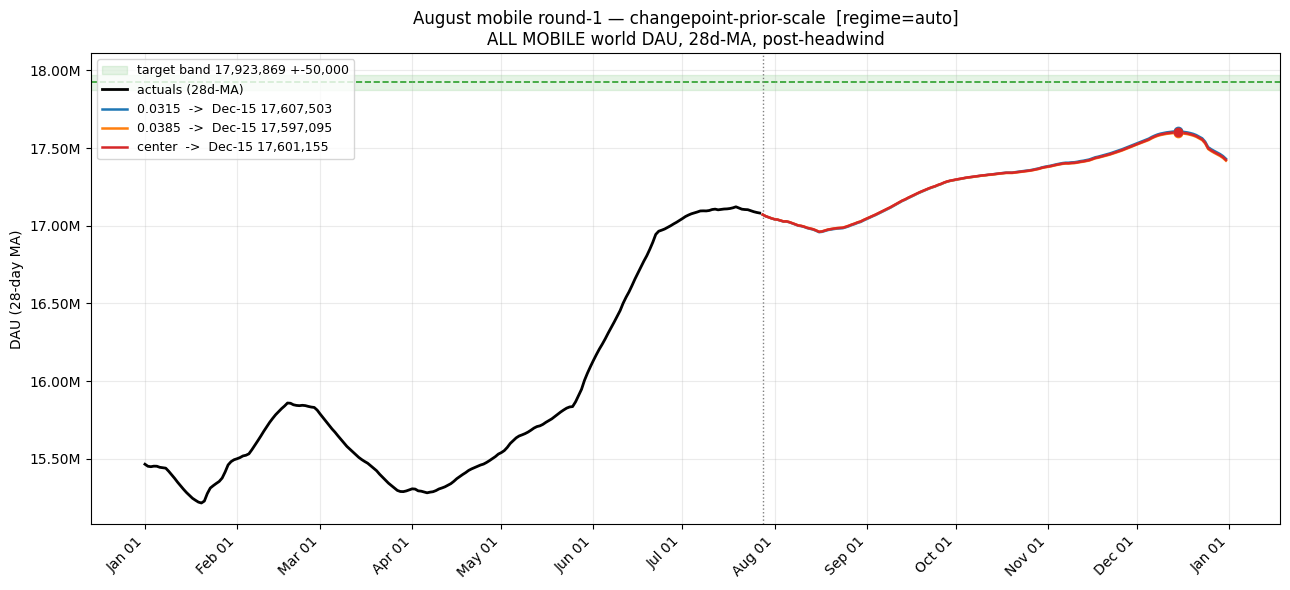

saved research/param-scans/mobile-aug/plots/round1_changepoint_range.png


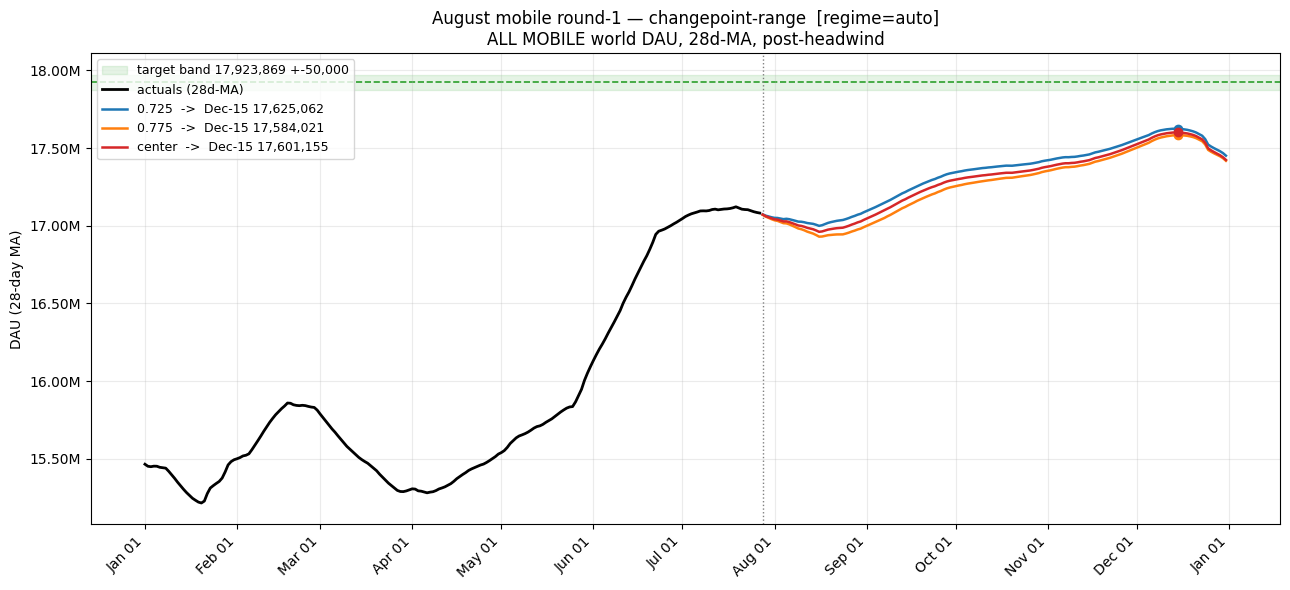

saved research/param-scans/mobile-aug/plots/round1_n_changepoints.png


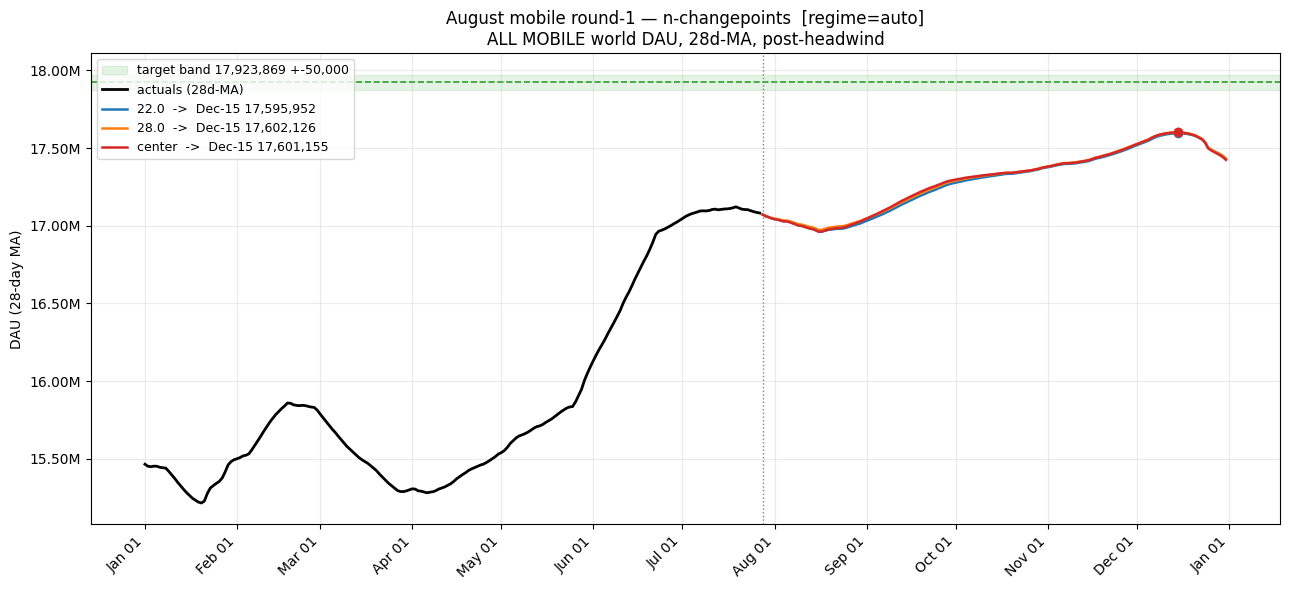

saved research/param-scans/mobile-aug/plots/round1_recent_weeks.png


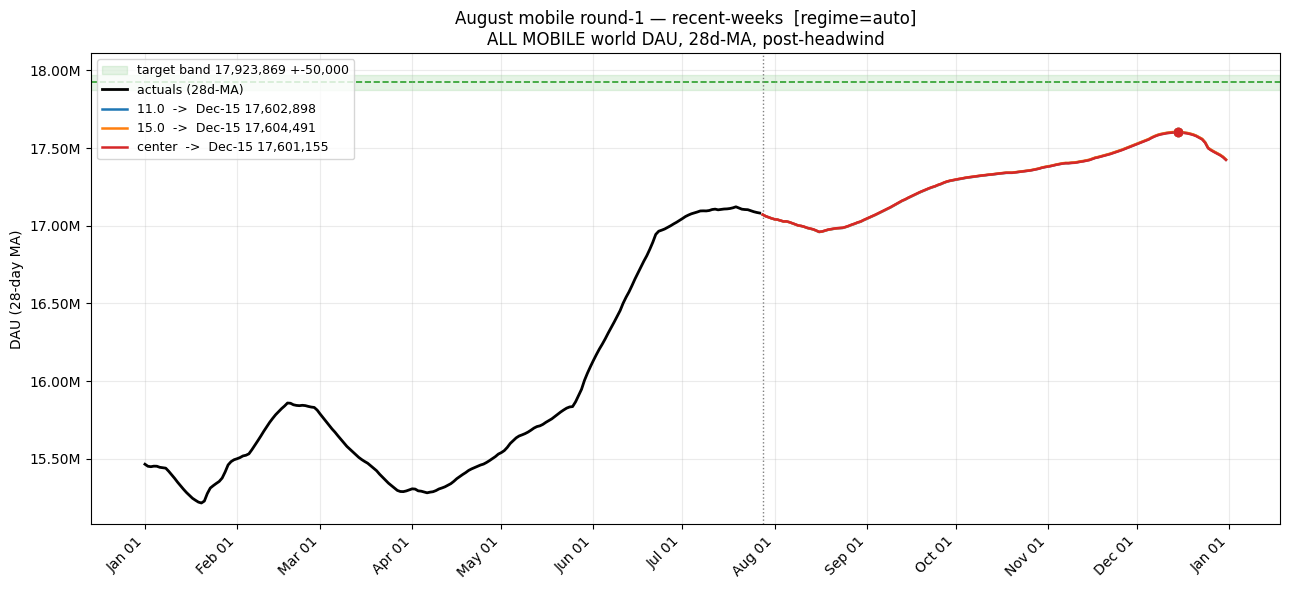

saved research/param-scans/mobile-aug/plots/round1_seasonality_prior_scale.png


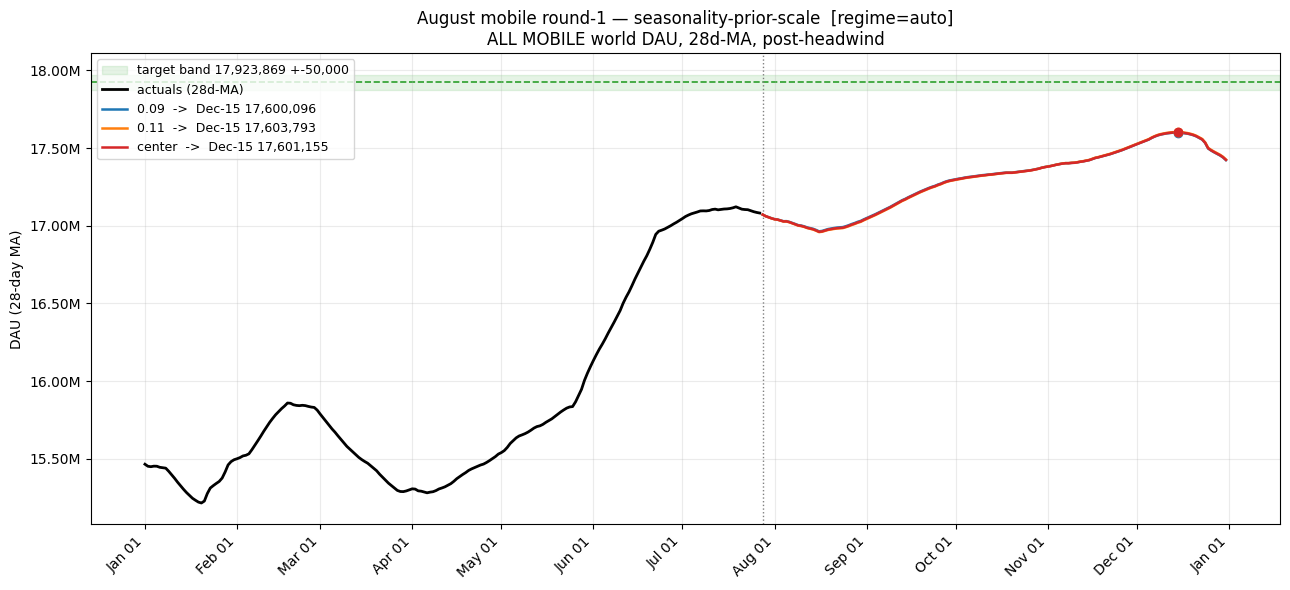

saved research/param-scans/mobile-aug/plots/round1_changepoint_prior_scale_multiplicative.png


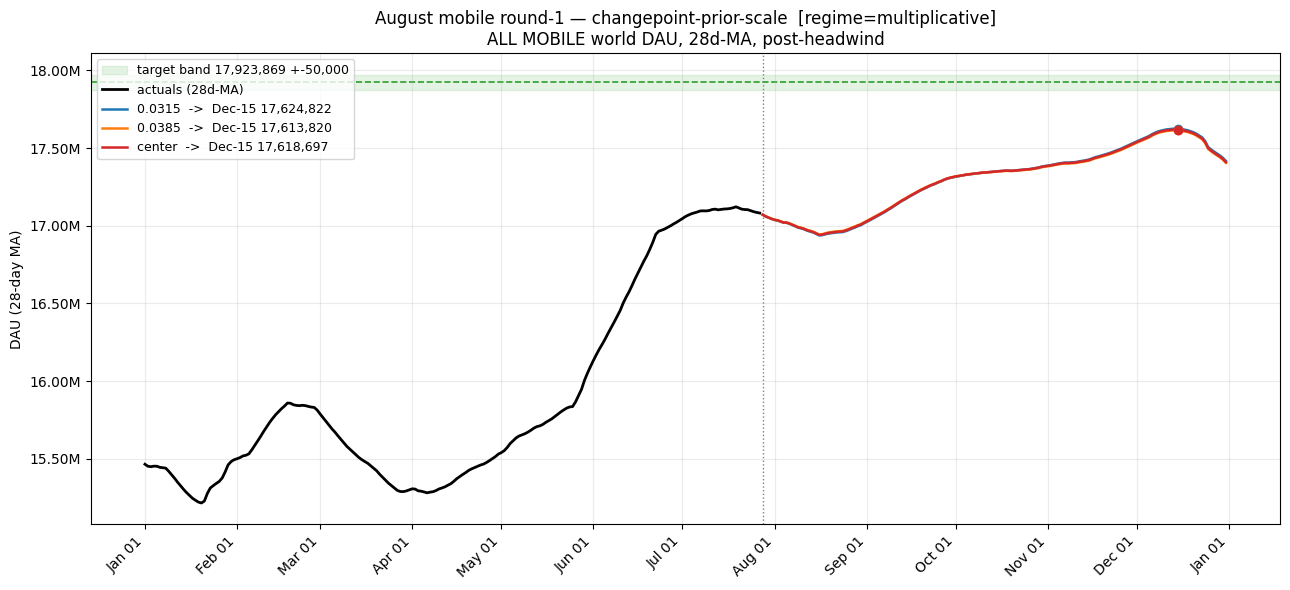

saved research/param-scans/mobile-aug/plots/round1_changepoint_range_multiplicative.png


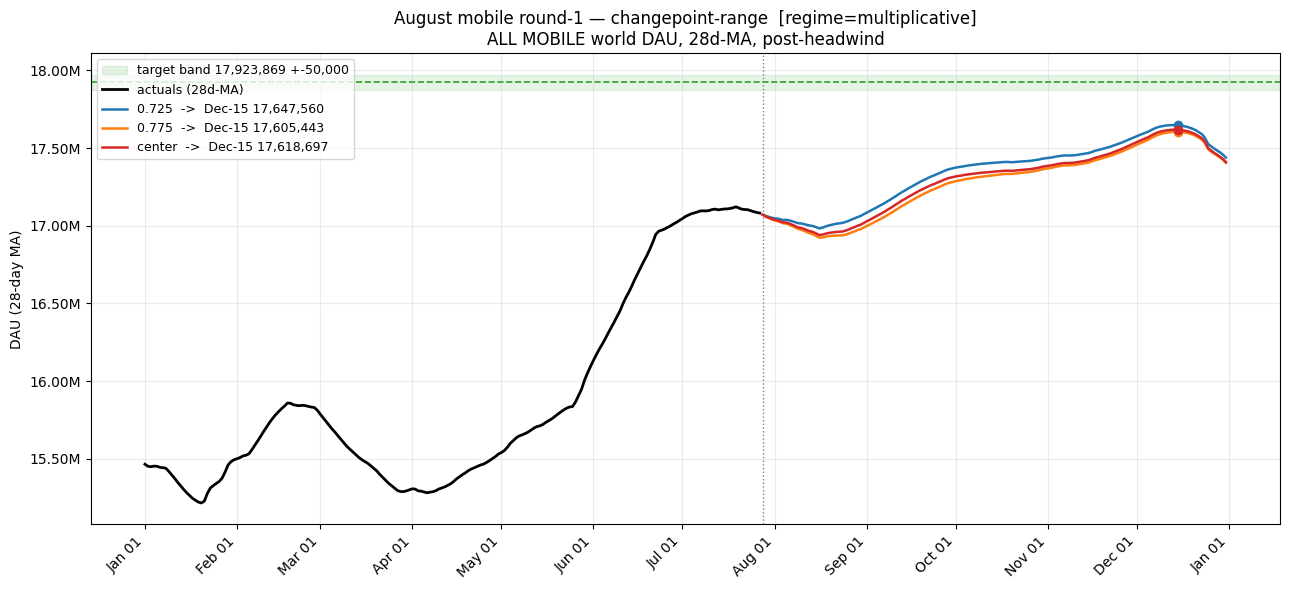

saved research/param-scans/mobile-aug/plots/round1_n_changepoints_multiplicative.png


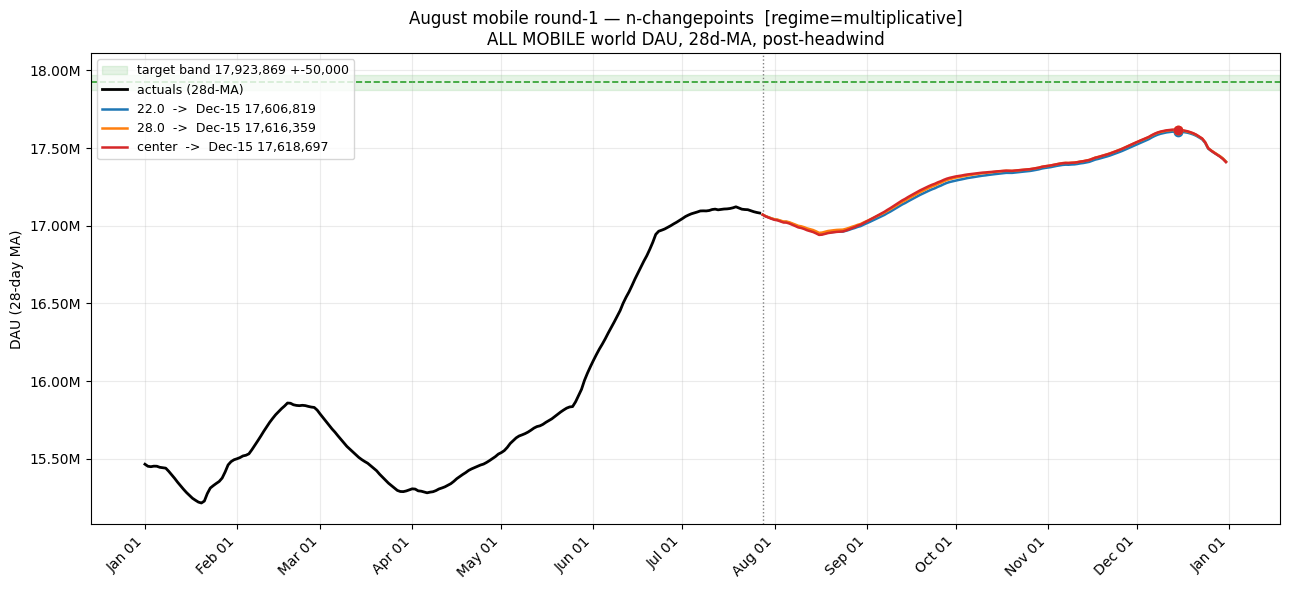

saved research/param-scans/mobile-aug/plots/round1_recent_weeks_multiplicative.png


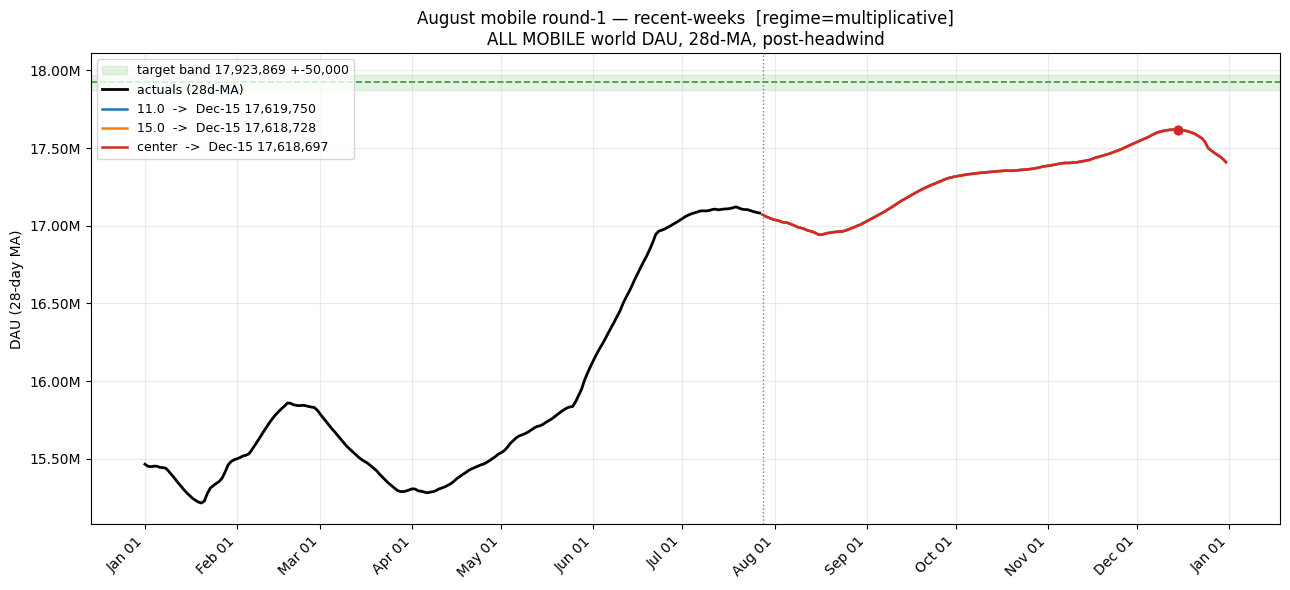

saved research/param-scans/mobile-aug/plots/round1_seasonality_prior_scale_multiplicative.png


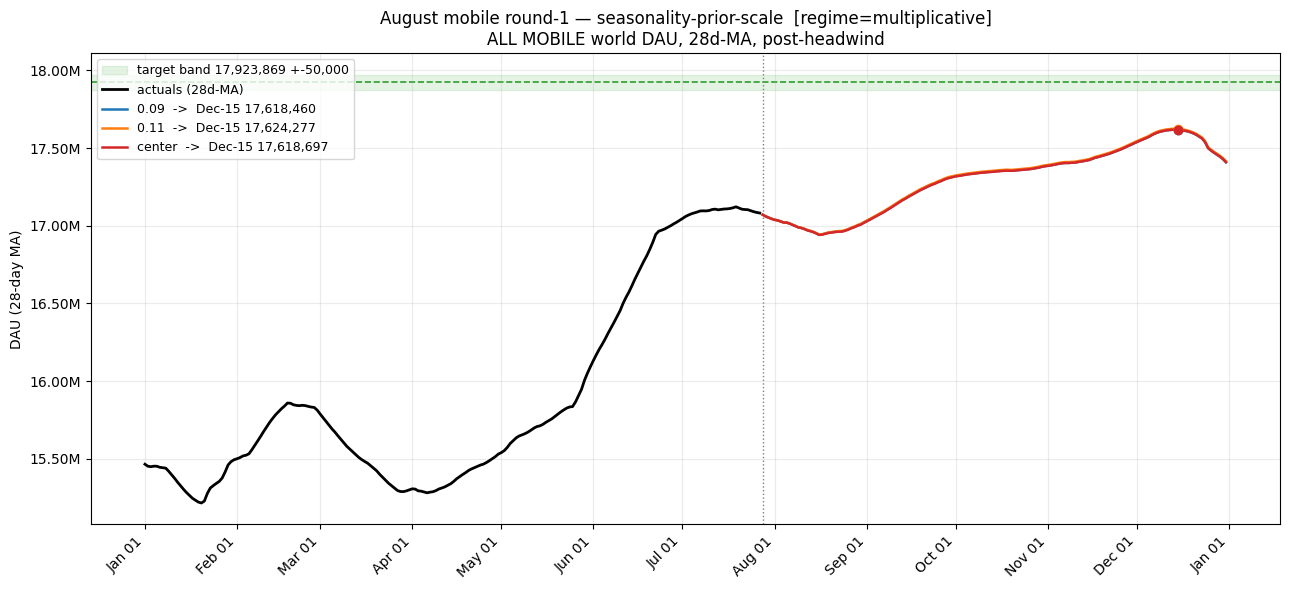

saved research/param-scans/mobile-aug/plots/round1_changepoint_prior_scale_additive.png


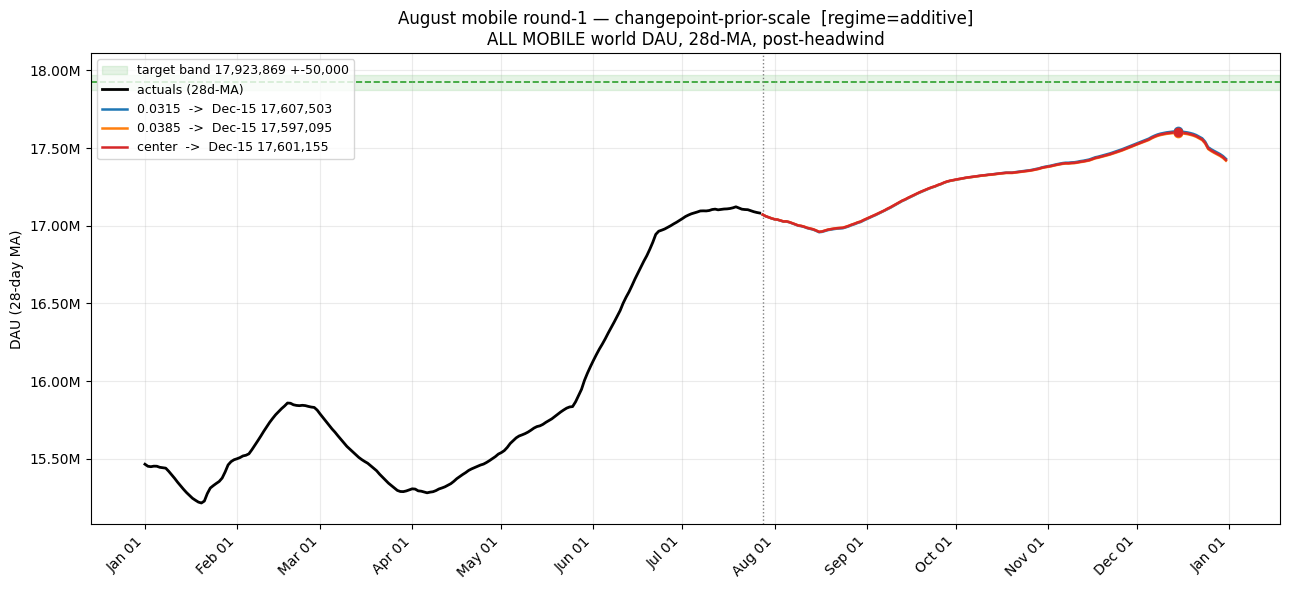

saved research/param-scans/mobile-aug/plots/round1_changepoint_range_additive.png


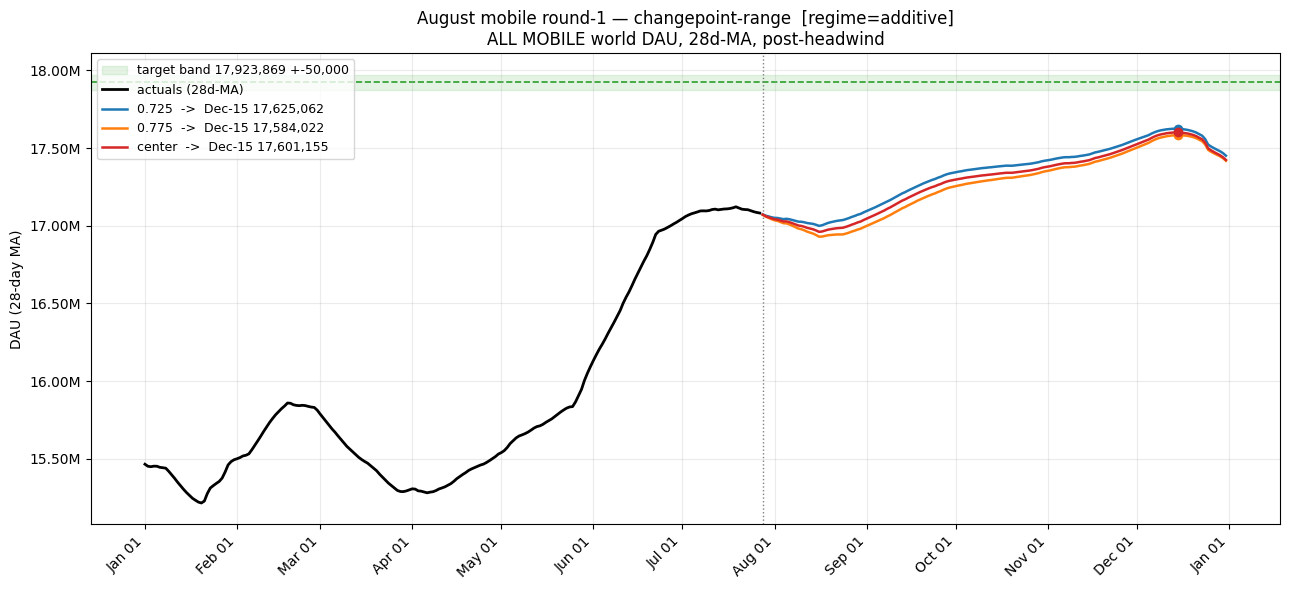

saved research/param-scans/mobile-aug/plots/round1_n_changepoints_additive.png


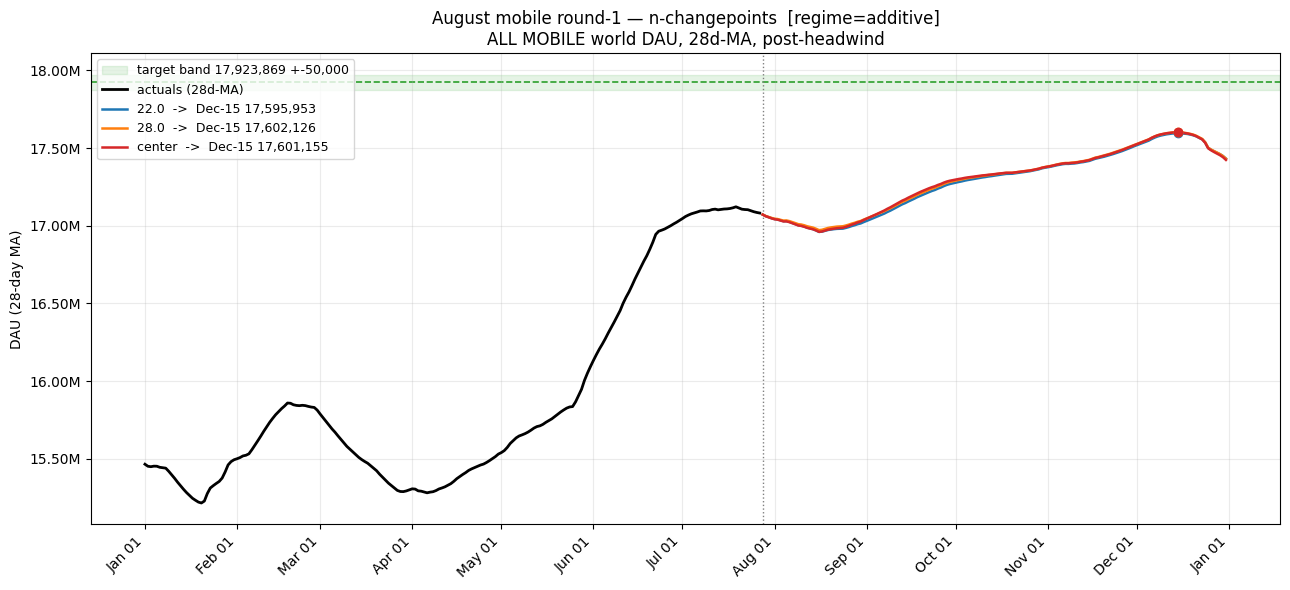

saved research/param-scans/mobile-aug/plots/round1_recent_weeks_additive.png


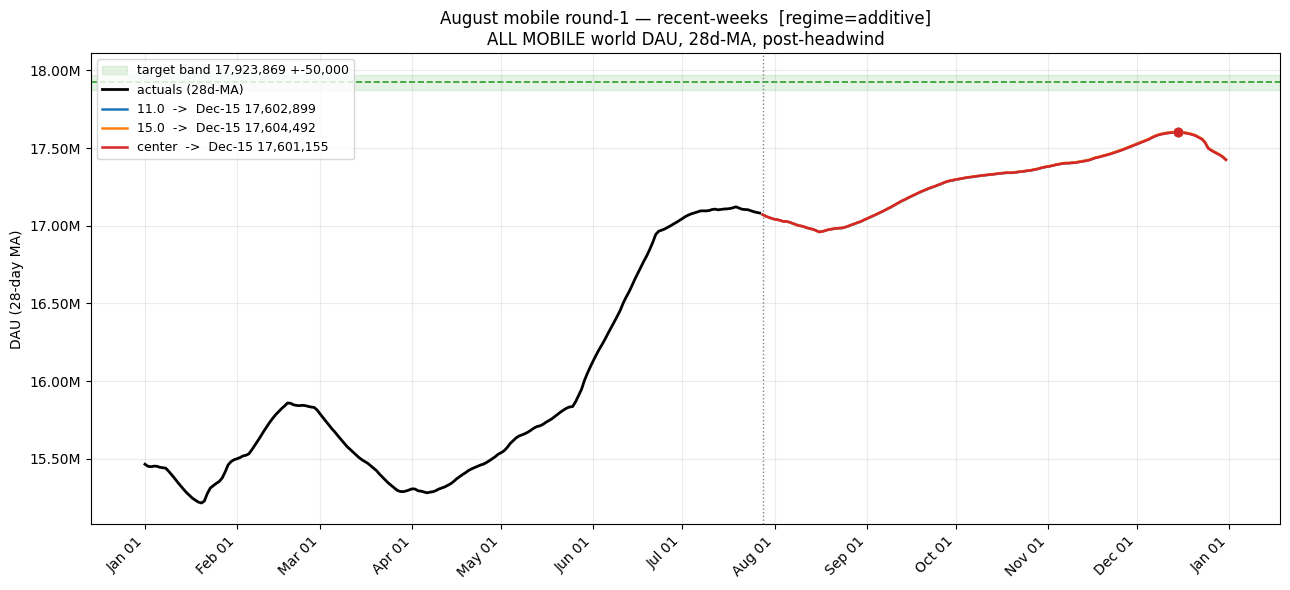

saved research/param-scans/mobile-aug/plots/round1_seasonality_prior_scale_additive.png


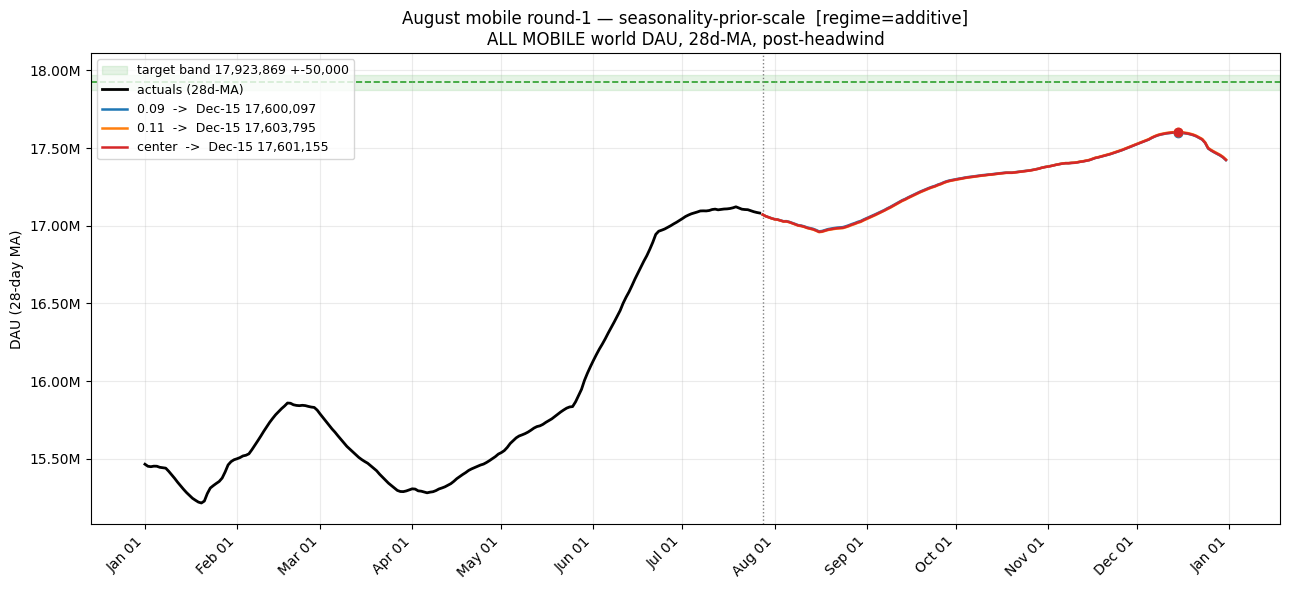

In [7]:
# [plot-per-axis]
# One canonical-format chart per axis, per regime: -delta / center / +delta post-headwind
# 28d-MA against actuals from Jan 1, target band shaded. This is the per-parameter validation
# plot the Dec-15 table cannot replace -- two configs can share a Dec-15 and disagree all year.
STYLES = {-1: ("tab:blue", "-"), 0: ("tab:red", "-"), 1: ("tab:orange", "-")}

for regime in REGIMES:
    s = scores[regime]
    for axis in deriv[regime]["axis"]:
        rows = pd.concat([s[s["axis"] == axis], s[s["axis"] == "(center)"]])
        fig, ax = base_axes(f"August mobile round-1 — {axis}  [regime={regime}]\n"
                            f"ALL MOBILE world DAU, 28d-MA, post-headwind")
        for _, row in rows.iterrows():
            color, ls = STYLES[int(row["sign"])]
            value = "center" if row["sign"] == 0 else f"{row['value']}"
            draw(ax, regime, row["label"], color, ls,
                 f"{value}  ->  Dec-15 {row['dec15_post']:,.0f}")
        ax.legend(loc="upper left", fontsize=9)
        suffix = "" if regime == "auto" else f"_{regime}"
        save(fig, f"round1_{axis.replace('-', '_')}{suffix}.png")

saved research/param-scans/mobile-aug/plots/round1_regime_comparison.png


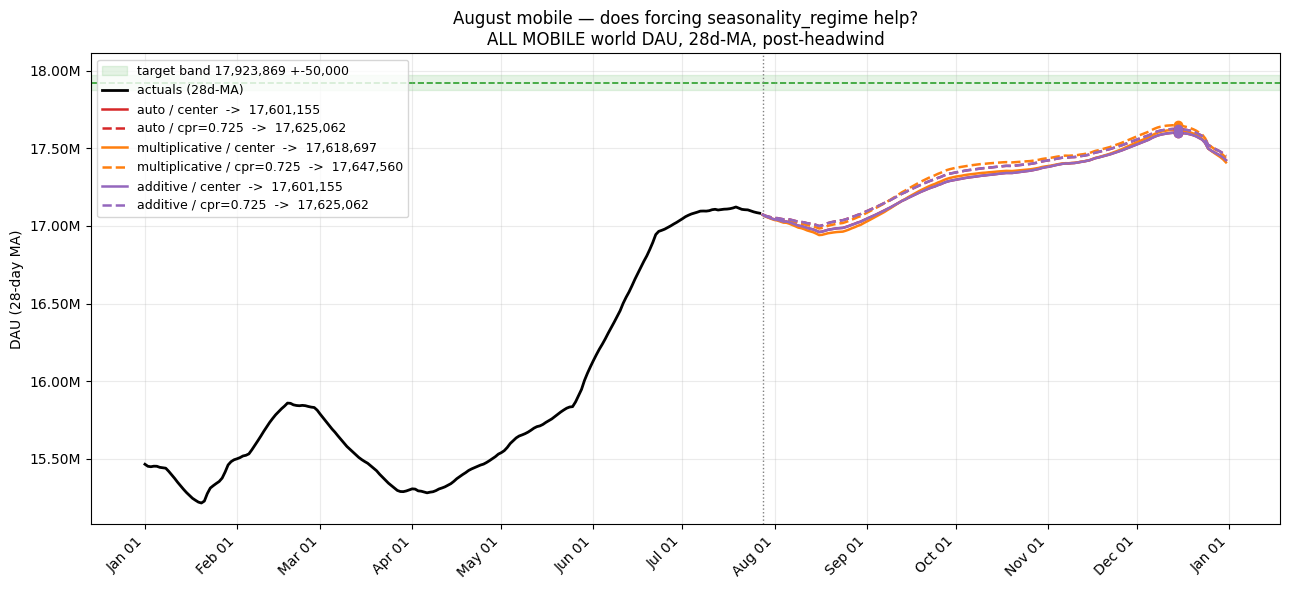

In [8]:
# [plot-regime]
# The regime question in one frame: both centers plus each regime's best probe (cpr at -delta,
# the only knob with meaningful pull). If forcing multiplicative were the missing lever, the
# orange pair would sit visibly closer to the green band.
fig, ax = base_axes("August mobile — does forcing seasonality_regime help?\n"
                    "ALL MOBILE world DAU, 28d-MA, post-headwind")
plan = [("auto", "center", "tab:red", "-"),
        ("auto", "changepoint-range__minus", "tab:red", "--"),
        ("multiplicative", "center", "tab:orange", "-"),
        ("multiplicative", "changepoint-range__minus", "tab:orange", "--"),
        ("additive", "center", "tab:purple", "-"),
        ("additive", "changepoint-range__minus", "tab:purple", "--")]
for regime, label, color, ls in plan:
    row = scores[regime].loc[scores[regime]["label"] == label].iloc[0]
    name = "center" if label == "center" else "cpr=0.725"
    draw(ax, regime, label, color, ls,
         f"{regime} / {name}  ->  {row['dec15_post']:,.0f}")
ax.legend(loc="upper left", fontsize=9)
save(fig, "round1_regime_comparison.png")

saved research/param-scans/mobile-aug/plots/round1_tornado.png


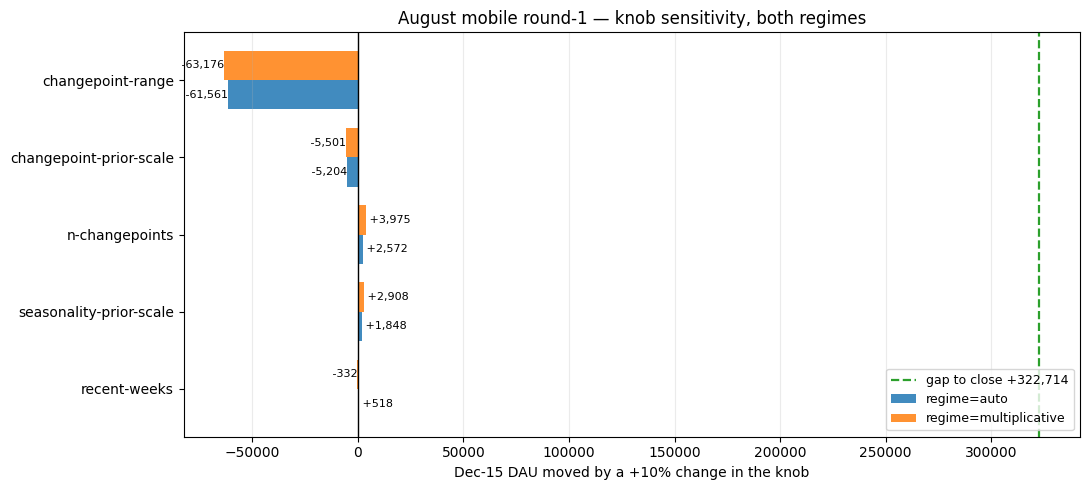

In [9]:
# [plot-tornado]
# Knob sensitivity on a common scale: DAU moved at Dec-15 by a +10% change in each knob, both
# regimes side by side. The dashed line is the gap. Every bar is a sliver against it -- that
# single visual is the round-1 result.
order = list(deriv["auto"].reindex(
    deriv["auto"]["effect_per_10pct"].abs().sort_values().index)["axis"])
width, y = 0.38, np.arange(len(order))

fig, ax = plt.subplots(figsize=(11, 5))
for offset, (regime, color) in zip((-width / 2, width / 2),
                                   [("auto", "tab:blue"), ("multiplicative", "tab:orange")]):
    d = deriv[regime].set_index("axis").reindex(order)
    ax.barh(y + offset, d["effect_per_10pct"], height=width, color=color,
            alpha=0.85, label=f"regime={regime}")
    for yy, v in zip(y + offset, d["effect_per_10pct"]):
        ax.text(v, yy, f" {v:+,.0f}", va="center",
                ha="left" if v > 0 else "right", fontsize=8)

ax.axvline(0, color="black", lw=1.0)
ax.axvline(GAP, color="tab:green", lw=1.6, ls="--", label=f"gap to close {GAP:+,.0f}")
ax.set_yticks(y)
ax.set_yticklabels(order)
ax.set_xlabel("Dec-15 DAU moved by a +10% change in the knob")
ax.set_title("August mobile round-1 — knob sensitivity, both regimes")
ax.grid(axis="x", alpha=0.25)
ax.legend(loc="lower right", fontsize=9)
save(fig, "round1_tornado.png")

In [10]:
# [reconciliation]
# WHY `additive` MOVES NOTHING -- and it is not a failed override.
#
# mozaic reconciles TOP-DOWN (`mozaic/utils.py`: metric_mozaics[m].reconcile_top_down()). The
# metric-level Mozaic forecasts the AGGREGATE series, then rescales the 64 country x app leaf
# tiles to sum to it. So a leaf tile's model form changes the ALLOCATION across countries; the
# world total is whatever the top-level fit says.
#
# mozaic's mobile model is volume-gated: under `auto` a tile is multiplicative iff max <= 2e6.
# The aggregate is ~16M, so the top-level fit is ALREADY additive under `auto`.
#   forcing additive       -> top-level fit unchanged        -> total unchanged
#   forcing multiplicative -> top-level fit flips            -> total moves
#
# The test below proves it: count how many leaves move, and compare the sum of their absolute
# moves against the change in the world total.
RESULTS = HERE / "results"
BASE = "cps0.035_thresh055_recent13_cpr0.75_ncp25_clip0.6_sps0.1"
SLUGS = {"auto": BASE, "multiplicative": BASE + "_regimemultiplicative",
         "additive": BASE + "_regimeadditive"}

snap = {}
for regime, slug in SLUGS.items():
    df, _ = load_forecast(
        str(RESULTS / slug / f"mozaic_daily_forecast.{FORECAST_START.date()}.gm-D.adj-p.parquet"),
        require_state=["p"])
    df["target_date"] = pd.to_datetime(df["target_date"])
    snap[regime] = df[df["target_date"] == DEC15]

rows = []
a = snap["auto"]
for regime in ("additive", "multiplicative"):
    m = a.merge(snap[regime], on=["country", "app_name", "segment"], suffixes=("_a", "_b"))
    leaf = m[(m["country"] != "ALL") & (m["app_name"] != "ALL MOBILE")]
    top = m[(m["country"] == "ALL") & (m["app_name"] == "ALL MOBILE")]
    delta = leaf["dau_b"] - leaf["dau_a"]
    rows.append({"regime": regime, "leaves_moved": int((delta.abs() > 1).sum()),
                 "leaves_total": len(leaf), "sum_abs_leaf_move": delta.abs().sum(),
                 "net_leaf_move": delta.sum(),
                 "world_total_move": float(top["dau_b"].iloc[0] - top["dau_a"].iloc[0])})
recon = pd.DataFrame(rows)
display(recon.style.format({"sum_abs_leaf_move": "{:,.0f}", "net_leaf_move": "{:+,.0f}",
                            "world_total_move": "{:+,.0f}"}))

print("Read the additive row: 63 of 64 leaves move, 27,552 DAU of absolute change, and the")
print("world total moves +1. The reallocation cancels because the total is pinned by the")
print("top-level fit. The knob is working; it just cannot reach this KPI.")
print()
print("CONSEQUENCE FOR THE SEARCH: the mobile world headline is, to first order, a SINGLE")
print("Prophet fit on the aggregate organic series. The 64 leaf tiles set allocation only.")
print("Any parameter whose effect varies across tiles will largely cancel at the total --")
print("only its effect on the top-level fit survives.")

,regime,leaves_moved,leaves_total,sum_abs_leaf_move,net_leaf_move,world_total_move
0,additive,63,64,"27,552",+1,+1
1,multiplicative,60,64,"11,343","+5,439","+5,439"


Read the additive row: 63 of 64 leaves move, 27,552 DAU of absolute change, and the
world total moves +1. The reallocation cancels because the total is pinned by the
top-level fit. The knob is working; it just cannot reach this KPI.

CONSEQUENCE FOR THE SEARCH: the mobile world headline is, to first order, a SINGLE
Prophet fit on the aggregate organic series. The 64 leaf tiles set allocation only.
Any parameter whose effect varies across tiles will largely cancel at the total --
only its effect on the top-level fit survives.


In [11]:
# [envelope]
# The reachable envelope across BOTH runs: every probe built, best first. This is the honest
# answer to "how close can these knobs get" -- it is a measured maximum over 22 configs, not
# an extrapolation.
allp = pd.concat([scores[r].assign(regime=r) for r in REGIMES], ignore_index=True)
allp["short"] = allp["regime"] + " / " + allp["label"]
best = allp.sort_values("dec15_post", ascending=False)

display(best[["short", "dec15_post", "gap_to_target", "yoy_dec15_pct",
              "seam_step", "seam_slope_kink"]].head(10)
        .style.format({"dec15_post": "{:,.0f}", "gap_to_target": "{:+,.0f}",
                       "yoy_dec15_pct": "{:.2f}", "seam_step": "{:+,.0f}",
                       "seam_slope_kink": "{:+,.0f}"}))

top = best.iloc[0]
print(f"\nBest of {len(allp)} probes: {top['short']} = {top['dec15_post']:,.0f}")
print(f"  still short of target by {TARGET - top['dec15_post']:,.0f}")
print(f"  full envelope: {allp['dec15_post'].min():,.0f} to {allp['dec15_post'].max():,.0f} "
      f"(spread {allp['dec15_post'].max() - allp['dec15_post'].min():,.0f})")
print(f"  target sits {TARGET - allp['dec15_post'].max():,.0f} above the top of it")
print(f"\nYoY across all probes: {allp['yoy_dec15_pct'].min():.2f}% to "
      f"{allp['yoy_dec15_pct'].max():.2f}%   (needed {YOY_NEEDED:.2f}%, "
      f"measured organic 11.60%)")

,short,dec15_post,gap_to_target,yoy_dec15_pct,seam_step,seam_slope_kink
14,multiplicative / changepoint-range__minus,"17,647,560","-276,309",12.64,"-8,941","-1,823"
25,additive / changepoint-range__minus,"17,625,062","-298,807",12.50,"-8,307","-1,014"
3,auto / changepoint-range__minus,"17,625,062","-298,807",12.50,"-8,304","-1,004"
12,multiplicative / changepoint-prior-scale__minus,"17,624,822","-299,047",12.50,"-10,868","-4,120"
21,multiplicative / seasonality-prior-scale__plus,"17,624,277","-299,592",12.50,"-10,630","-3,833"
18,multiplicative / recent-weeks__minus,"17,619,750","-304,119",12.47,"-10,655","-3,881"
19,multiplicative / recent-weeks__plus,"17,618,728","-305,141",12.46,"-10,688","-3,927"
11,multiplicative / center,"17,618,697","-305,172",12.46,"-10,719","-3,956"
20,multiplicative / seasonality-prior-scale__minus,"17,618,460","-305,409",12.46,"-10,663","-3,887"
17,multiplicative / n-changepoints__plus,"17,616,359","-307,510",12.45,"-9,987","-3,156"



Best of 33 probes: multiplicative / changepoint-range__minus = 17,647,560
  still short of target by 276,309
  full envelope: 17,584,021 to 17,647,560 (spread 63,539)
  target sits 276,309 above the top of it

YoY across all probes: 12.24% to 12.64%   (needed 14.41%, measured organic 11.60%)


In [12]:
# [seam-report]
# REPORTED, NOT TRAINED ON. Per the search brief, nothing here enters selection; it exists so
# a config that hits Dec-15 by mangling the actuals->forecast handoff is visible.
#
# `seam_step` is the level discontinuity (forecast 28d-MA on the first forecast day minus the
# actuals' own trailing 28d-MA on the last training day). Under `p` a small step is expected
# by construction: training rows carry MEASURED paid, forecast rows carry MARKETING's paid
# level, and the two disagree at the seam.
seam = allp[["short", "value", "seam_actual_ma", "seam_forecast_ma", "seam_step",
             "seam_step_pct", "seam_slope_before", "seam_slope_after", "seam_slope_kink"]]
display(seam.style.format({
    "seam_actual_ma": "{:,.0f}", "seam_forecast_ma": "{:,.0f}", "seam_step": "{:+,.0f}",
    "seam_step_pct": "{:+.3f}", "seam_slope_before": "{:+,.0f}",
    "seam_slope_after": "{:+,.0f}", "seam_slope_kink": "{:+,.0f}"}))

print(f"\nseam step across all probes: {allp['seam_step'].min():+,.0f} to "
      f"{allp['seam_step'].max():+,.0f}")
print(f"slope kink across all probes: {allp['seam_slope_kink'].min():+,.0f} to "
      f"{allp['seam_slope_kink'].max():+,.0f}")
print("\nNote the direction that helps Dec-15 (lower cpr) also IMPROVES the handoff, and that "
      "forcing multiplicative slightly worsens it.")

,short,value,seam_actual_ma,seam_forecast_ma,seam_step,seam_step_pct,seam_slope_before,seam_slope_after,seam_slope_kink
0,auto / center,nan,"17,082,290","17,072,301","-9,989",-0.058,"-2,051","-5,005","-2,954"
1,auto / changepoint-prior-scale__minus,0.031500,"17,082,290","17,072,200","-10,090",-0.059,"-2,051","-5,125","-3,074"
2,auto / changepoint-prior-scale__plus,0.038500,"17,082,290","17,072,355","-9,935",-0.058,"-2,051","-4,959","-2,908"
3,auto / changepoint-range__minus,0.725000,"17,082,290","17,073,986","-8,304",-0.049,"-2,051","-3,055","-1,004"
4,auto / changepoint-range__plus,0.775000,"17,082,290","17,070,983","-11,307",-0.066,"-2,051","-6,537","-4,486"
5,auto / n-changepoints__minus,22.000000,"17,082,290","17,072,513","-9,777",-0.057,"-2,051","-4,910","-2,859"
6,auto / n-changepoints__plus,28.000000,"17,082,290","17,072,922","-9,369",-0.055,"-2,051","-4,343","-2,293"
7,auto / recent-weeks__minus,11.000000,"17,082,290","17,072,253","-10,038",-0.059,"-2,051","-5,066","-3,015"
8,auto / recent-weeks__plus,15.000000,"17,082,290","17,072,274","-10,016",-0.059,"-2,051","-5,039","-2,988"
9,auto / seasonality-prior-scale__minus,0.090000,"17,082,290","17,072,462","-9,828",-0.058,"-2,051","-4,837","-2,786"



seam step across all probes: -11,400 to -8,304
slope kink across all probes: -4,765 to -1,004

Note the direction that helps Dec-15 (lower cpr) also IMPROVES the handoff, and that forcing multiplicative slightly worsens it.


In [13]:
# [extrapolation]
# Single-knob linear extrapolations to close the whole gap. These are ROUND-2 STARTING POINTS,
# NOT PREDICTIONS. Two independent reasons they will be wrong:
#   1. own-curvature -- `nonlinearity` says how much the quadratic term contributes over just a
#      10% move; extrapolating far past that compounds it.
#   2. cross-parameter interaction -- every prior search on this codebase found that combining
#      two knobs does not equal the sum of their individual effects. A +-delta gradient cannot
#      see this at all; only a combined cell can.
BOUNDS = {"changepoint-range": (0.0, 1.0), "n-changepoints": (1, 200),
          "recent-weeks": (2, 104), "changepoint-prior-scale": (0.001, 1.0),
          "seasonality-prior-scale": (0.001, 20.0)}

for regime in REGIMES:
    d = deriv[regime]
    gap_here = TARGET - float(centers[regime]["dec15_post"])
    print(f"\n=== regime={regime}   gap {gap_here:+,.0f} ===")
    print(f"{'axis':<28}{'center':>10}{'linear target':>16}{'% move':>10}"
          f"{'reachable?':>14}{'nonlin':>9}")
    ranked = d.reindex(d["effect_per_10pct"].abs().sort_values(ascending=False).index)
    for _, r in ranked.iterrows():
        # Recompute against THIS regime's own center rather than reusing the auto gap.
        target_value = r["center"] + gap_here / r["d1"] if r["d1"] else float("nan")
        pct = (target_value - r["center"]) / r["center"] * 100
        lo, hi = BOUNDS.get(r["axis"], (-np.inf, np.inf))
        ok = "yes" if lo <= target_value <= hi else "OUT OF RANGE"
        print(f"{r['axis']:<28}{r['center']:>10}{target_value:>16,.4f}{pct:>+9.1f}%"
              f"{ok:>14}{r['nonlinearity']:>9.1%}")


=== regime=auto   gap +322,714 ===
axis                            center   linear target    % move    reachable?   nonlin
changepoint-range                 0.75          0.3568    -52.4%           yes    49.5%
changepoint-prior-scale          0.035         -0.1821   -620.1%  OUT OF RANGE    22.0%
n-changepoints                    25.0        338.6225  +1254.5%  OUT OF RANGE    57.1%
seasonality-prior-scale            0.1          1.8459  +1745.9%           yes    42.7%
recent-weeks                      13.0        823.0704  +6231.3%  OUT OF RANGE   207.2%

=== regime=multiplicative   gap +305,172 ===
axis                            center   linear target    % move    reachable?   nonlin
changepoint-range                 0.75          0.3877    -48.3%           yes   111.2%
changepoint-prior-scale          0.035         -0.1592   -554.7%  OUT OF RANGE    11.3%
n-changepoints                    25.0        216.9218   +767.7%  OUT OF RANGE   124.2%
seasonality-prior-scale            0.1

In [14]:
# [cpr-meaning]
# What a large changepoint_range move actually means. cpr is the FRACTION of the training
# window in which Prophet may place changepoints, so lowering it freezes the trend estimate
# further into the past -- and the extrapolated single-knob target lands in 2022.
train_start, train_end = actual.index.min(), actual.index.max()
span = (train_end - train_start).days
print(f"mobile training window: {train_start.date()} -> {train_end.date()}  ({span} days)\n")
print(f"{'cpr':>8}{'last changepoint':>20}{'history left unhinged':>24}")
for cpr, note in [(0.82, "package default"), (0.775, "probe +d"), (0.75, "SHIPPED"),
                  (0.725, "probe -d"), (0.60, ""), (0.50, ""), (0.3568, "extrapolated target")]:
    last = train_start + pd.Timedelta(days=round(span * cpr))
    print(f"{cpr:>8}{str(last.date()):>20}{span - round(span * cpr):>19,} d   {note}")
print("\nAt the extrapolated value the trend is pinned to the 2021-2022 regime and the last")
print("~3.6 years cannot bend it. That is plausibly WHY it lifts Dec-15 -- it recovers the")
print("steeper pre-paid-era slope, which is the same signal `p` was adopted to remove.")

mobile training window: 2020-12-31 -> 2026-07-27  (2034 days)

     cpr    last changepoint   history left unhinged
    0.82          2025-07-26                366 d   package default
   0.775          2025-04-25                458 d   probe +d
    0.75          2025-03-06                508 d   SHIPPED
   0.725          2025-01-14                559 d   probe -d
     0.6          2024-05-04                814 d   
     0.5          2023-10-14              1,017 d   
  0.3568          2022-12-27              1,308 d   extrapolated target

At the extrapolated value the trend is pinned to the 2021-2022 regime and the last
~3.6 years cannot bend it. That is plausibly WHY it lifts Dec-15 -- it recovers the
steeper pre-paid-era slope, which is the same signal `p` was adopted to remove.


## Conclusion

**No combination of the exposed non-holiday knobs reaches 17,923,869 from this center at
defensible magnitudes.**

- Across all 22 probes the Dec-15 envelope is ~17.58M–17.65M. The target sits **~275K above
  the top of it**.
- `changepoint_range` is the only knob with real pull, and it points **down**. Its
  single-knob extrapolation (≈0.36) would confine every changepoint to before end-2022 —
  see `[cpr-meaning]`. Its curvature over that distance exceeds its linear term, so the
  extrapolation is not even a reliable estimate of what that config would produce.
- **Forcing `seasonality_regime='multiplicative'` is a dud on mobile**: +17,542 at Dec-15,
  5.4% of the gap, and it slightly worsens the seam handoff. This is the opposite of desktop,
  where the same switch was the largest single lever — because on mobile the regime sets
  `seasonality_mode` only, while on desktop it also flips linear/logistic growth.
- YoY across every probe spans 12.24–12.64%, against **14.41%** required and **11.60%**
  measured organic. The whole reachable neighbourhood is ~1.8pp short.

## Reading this

- **Rank by `effect_per_10pct`, not `d1`.** Units differ by three orders of magnitude.
- **`nonlinearity` is the trust metric for the extrapolation** — the quadratic term's share
  of the linear term over a 10% move.
- **A ± gradient cannot see cross-parameter interaction**, which every prior search on this
  codebase found material. Only a combined cell can.
- **Seam numbers are reported only.** Nothing in the selection rule touches them.
- **`seasonality_corr_threshold` is not available on mobile** — `MobileModelConfig` raises on
  any non-zero value, because mobile's regime switch is volume-driven rather than
  correlation-driven. Desktop-only; do not re-propose it.
- **Holiday knobs stay excluded** by standing policy.